# Heuristic Search

You have managed to land the next-gen robot explorer on the surface of MARS.
It comes equipped with the latest topography data, and a very clever, heuristic search algorithm that it can use to find the optimal path between two points it needs to travel.

**Optimal** here means using the least possible energy.

The robot spends energy when going uphill (from lower to higher elevation) at a rate that is quadratic with the difference in height.
The robot can recharge its battery when going downhill at a rate that is (sadly) only linear with the difference in height.

Your task is to:  
1. Build a graph of the selected section of MARS.  
2. Create a search algorithm (based on UCS) to find a path between two points that results in the robot spending the least amount of energy.  
3. Figure out what is the best way to define the edge weights (different definitions will give you different paths).  
4. Experiment and see what happens when you change the energy cost for the robot to go up or down hill.  
5. Next, you may further define `h_n`, the cost-to-go heuristic function to inform the search algorithm to minimize the number of node expansions.

### Credits
Original code written by Francisco Estrada, Jan. 2020  
Adopted by Bryan Chan, Nov. 2024

In [1]:
# Uncomment below of interactive mode
# import matplotlib
# %matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import os

from enum import Enum
from itertools import product
from matplotlib.image import imread
from matplotlib.patches import Circle
from typing import Tuple, Callable

## Loading the image

In [2]:
image = imread("mars_elevation.jpg")

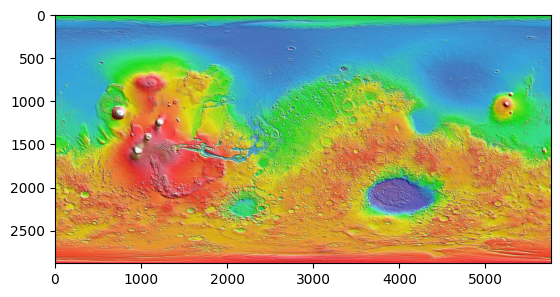

In [3]:
plt.imshow(image)
plt.show()

In [4]:
plt.close()

In [5]:
# Compute the min and max values
print("Min: {}, Max: {}".format(np.min(image), np.max(image)))

# Print image shape
print("Shape: {}".format(image.shape))

Min: 0, Max: 255
Shape: (2880, 5760, 3)


## Cost Functions

In [6]:
def upward_cost(delta: float) -> float:
    """
    Computes the cost when robot is going uphill.
    This must return a positive cost.

    Args:
    - delta (float): the elevation change from one location to another.
    """
    return delta ** 2

def downward_cost(delta: float) -> float:
    """
    Computes the cost when robot is going downhill.
    This must return a negative cost.

    Args:
    - delta (float): the elevation change from one location to another.
    """
    return delta

## Path Finding Function

In [7]:
PIXEL_DELTA = np.array([
    [-1, 0],
    [1, 0],
    [0, -1],
    [0, 1],
])

def construct_graph(map_elevation: np.ndarray) -> np.ndarray:
    """
    Computes the graph, G (ndarray), given the elevation map, map_elevation (ndarray).

    G corresponds to a 4-D array, where
    1. the first two dimensions correspond to the current location,
    2. the third dimension correponds to a direction in order
       (TOP, BOTTOM, LEFT, RIGHT),
    3. the last dimension corresponds to the neighbour pixel location
       and edge weight, i.e., (neighbour_x, neighbour_y, weight)

    In other words, accessing G[0, 0, 1] corresponds to accessing the pixel location
    and the weight of the BOTTOM neighbour of pixel at (0, 0), which should be
    (1, 0, edge_weight).
    
    When the direction leads to no neighbour, we leave the values as infinity.

    NOTE: Beware that x-axis corresponds to the second dimension
          and y-axis corresponds to the first dimension
    """
    region_size = map_elevation.shape[0]
    G = np.full((region_size, region_size, 4, 3), fill_value=np.inf)

    for (curr_x, curr_y) in product(range(region_size), range(region_size)):
        for direction in range(4):
            neighbour = np.array([curr_y, curr_x]) + PIXEL_DELTA[direction]
            if np.any(neighbour < 0) or np.any(neighbour >= region_size):
                continue
            
            curr_elevation = map_elevation[curr_y, curr_x]
            neighbour_elevation = map_elevation[neighbour[0], neighbour[1]]
            delta = neighbour_elevation - curr_elevation


            G[curr_y, curr_x, direction] = (neighbour[0], neighbour[1], upward_cost(delta) if delta > 0 else downward_cost(delta))
            

    return G

In [8]:
import heapq
def graph_search(G, source_x, source_y, goal_x, goal_y, h_n=lambda *args, **kwargs: 0):
    """
    Computes the path between the source and the goal using uniform-cost search.
    If there is no path between source and goal, return empty list.

    Args:
    - G (ndarray): the graph G
    - source_x (int): the x-value of the source pixel.
    - source_y (int): the y-value of the source pixel.
    - goal_x (int): the x-value of the goal pixel.
    - goal_y (int): the y-value of the goal pixel.
    - h_n (Callable): the heuristic function.
    """
    print("Finding path from ({}, {}) to ({}, {})".format(source_x, source_y, goal_x, goal_y))

    P = []
    expanded = np.full(G.shape[:2], fill_value=-1)
    curr_expanded = 0
    
    pqueue = [(0, (source_y,source_x), [])]
    cost = {(source_y, source_x): 0}
    visited = set()
    while pqueue:
        curr_cost, curr_pos, path = heapq.heappop(pqueue)
        # If unvisited mark down previous position and cost to get here
        curr_y,curr_x = curr_pos
        
        if curr_pos in visited:
            continue
        
        visited.add(curr_pos)
        
        path = path + [curr_pos]
        
        expanded[curr_y][curr_x] = curr_expanded
        curr_expanded += 1
        # At the goal
        if curr_y == goal_y and curr_x == goal_x:
            return path, expanded
        
        for direction in range(4):
            n_y, n_x, weight = G[curr_y, curr_x, direction]
            if np.isinf(weight):
                continue
            
            n_y, n_x = int(n_y), int(n_x)
            new_cost = curr_cost + weight + h_n(source_x, source_y, goal_x, goal_y, n_y, n_x)
            if (n_y,n_x) not in visited or new_cost < cost.get((n_y,n_x)):
                cost[(n_y,n_x)] = new_cost
                heapq.heappush(pqueue, (new_cost, (n_y,n_x), path))
    return P, expanded

In [9]:
def path_finding(
    region_size: int,
    center_x: int,
    center_y: int,
    source_x: int,
    source_y: int,
    goal_x: int,
    goal_y: int,
    h_n: Callable
) -> Tuple[np.ndarray, np.ndarray, float, np.ndarray]:
    """
    Computes and returns:
    - the graph, G (ndarray)
    - the path found, P (ndarray)
    - the corresponding cost, C (float)
    - the expansion order, expanded (ndarray).

    Args:
    - region_size (int): The size of the sub-region, in pixels, where we run the path-finding algorithm.
    - center_x (int): the (absolute) x-value of the sub-region's center.
    - center_y (int): the (absolute) y-value of the sub-region's center.
    - source_x (int): the (absolute) x-value of the source pixel.
    - source_y (int): the (absolute) y-value of the source pixel.
    - goal_x (int): the (absolute) x-value of the goal pixel.
    - goal_y (int): the (absolute) y-value of the goal pixel.
    - h_n (Callable): the heuristic function for cost-to-go.
    """
    # Load the image
    image = imread("mars_elevation.jpg")

    # Compute the average brightness, which corresponds to the elevation
    map_elevation = np.mean(image, axis=-1)
    
    start_padding = int(np.floor(region_size / 2))
    end_padding = int(np.ceil(region_size / 2))
    start_x = center_x - start_padding
    start_y = center_y - start_padding

    end_x = center_x + end_padding
    end_y = center_y + end_padding
    
    assert 0 <= start_x < end_x < map_elevation.shape[1]
    assert 0 <= start_y < end_y < map_elevation.shape[0]

    assert start_x <= source_x < end_x
    assert start_y <= source_y < end_y
    assert start_x <= goal_x < end_x
    assert start_y <= goal_y < end_y

    map_elevation = map_elevation[start_y:end_y, start_x:end_x]

    G = None
    P = None
    C = None

    G = construct_graph(map_elevation)
    P, expanded = graph_search(
        G,
        source_x - start_x,
        source_y - start_y,
        goal_x - start_x,
        goal_y - start_y,
        h_n,
    )
    C = 0
    for curr_pixel, next_pixel in zip(P[:-1], P[1:]):
        curr_elevation = map_elevation[curr_pixel[0], curr_pixel[1]]
        next_elevation = map_elevation[next_pixel[0], next_pixel[1]]
        delta = next_elevation - curr_elevation
        curr_cost = upward_cost(delta) if delta > 0 else downward_cost(delta)
        C = C + curr_cost

    print("Cost: {}".format(C))
    return G, P, C, expanded

In [10]:
image.shape

(2880, 5760, 3)

In [11]:
def h_n(source_x, source_y, goal_x, goal_y, curr_x, curr_y):
    """
    Computes the cost-to-go from node at location (curr_x, curr_y)

    Args:
    - source_x (int): the (absolute) x-value of the source pixel.
    - source_y (int): the (absolute) y-value of the source pixel.
    - goal_x (int): the (absolute) x-value of the goal pixel.
    - goal_y (int): the (absolute) y-value of the goal pixel.
    - curr_x (int): the (absolute) x-value of the current pixel.
    - curr_y (int): the (absolute) y-value of the current pixel.
    """
    return abs(curr_x-goal_x) + abs(curr_y - goal_y)

In [12]:
region_size = 250
center_x = 500
center_y = 1000
source_x = center_x + 50
source_y = center_y + 50
goal_x = center_x - 100
goal_y = center_y + 100

G, P, C, expanded = path_finding(
    region_size,
    center_x,
    center_y,
    source_x,
    source_y,
    goal_x,
    goal_y,
    h_n
)

Finding path from (175, 175) to (25, 225)
Cost: 32390.44444444446


211


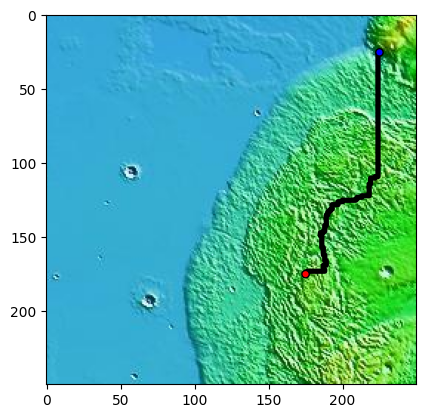

In [13]:
start_padding = int(np.floor(region_size / 2))
end_padding = int(np.ceil(region_size / 2))
start_x = center_x - start_padding
start_y = center_y - start_padding
end_x = center_x + end_padding
end_y = center_y + end_padding

fig, ax = plt.subplots(1, 1)
ax.imshow(image[start_y:end_y, start_x:end_x])

print(len(P))
for curr_node in P:
    circ = Circle(
        (curr_node[0], curr_node[1]),
        region_size * 0.005,
        facecolor="black",
        edgecolor="black",
    )
    ax.add_patch(circ)

for (xx, yy, cc) in (
    (source_x, source_y, "red"),
    (goal_x, goal_y, "blue"),
):
    circ = Circle(
        (yy - start_y, xx - start_x),
        region_size * 0.01,
        facecolor=cc,
        edgecolor="black",
    )
    ax.add_patch(circ)

plt.show()

In [14]:
plt.close()

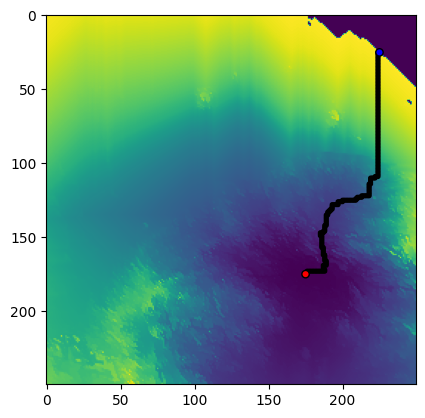

In [15]:
fig, ax = plt.subplots(1, 1)

ax.imshow(expanded.T)

for curr_node in P:
    circ = Circle(
        (curr_node[0], curr_node[1]),
        region_size * 0.005,
        facecolor="black",
        edgecolor="black",
    )
    ax.add_patch(circ)

for (xx, yy, cc) in (
    (source_x, source_y, "red"),
    (goal_x, goal_y, "blue"),
):
    circ = Circle(
        (yy - start_y, xx - start_x),
        region_size * 0.01,
        facecolor=cc,
        edgecolor="black",
    )
    ax.add_patch(circ)

plt.show()

In [16]:
plt.close()